# Usage demo: analysis channelizer

A polyphase analysis channelizer splits a wideband input stream into `M` narrowband
channels. Each channel output is decimated by a factor `D` (equal to `M` for
critically-sampled operation), so the output sample rate is `fs / D`.

This notebook works through a concrete example:

1. Show the filter bank's channel frequency responses.
2. Build a composite signal with tones at known frequencies — some at channel
   bin centers, one at a channel boundary.
3. Process the signal and inspect the per-channel PSDs.

In [1]:
import sys
from pathlib import Path

_src = Path.cwd().parent / "src"
if _src.exists() and str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

from pypoly import PolyphaseAnalysisChannelizer

%matplotlib inline

M = 8
TAPS_PER_CHANNEL = 16

## Filter bank channel responses

Before processing any signal, it is useful to characterise the filter bank itself.
Each of the `M` output channels is a frequency-shifted copy of the same prototype
low-pass filter. Sweeping a pure tone across the full band and recording the
steady-state output power in every channel traces out all `M` passbands at once.

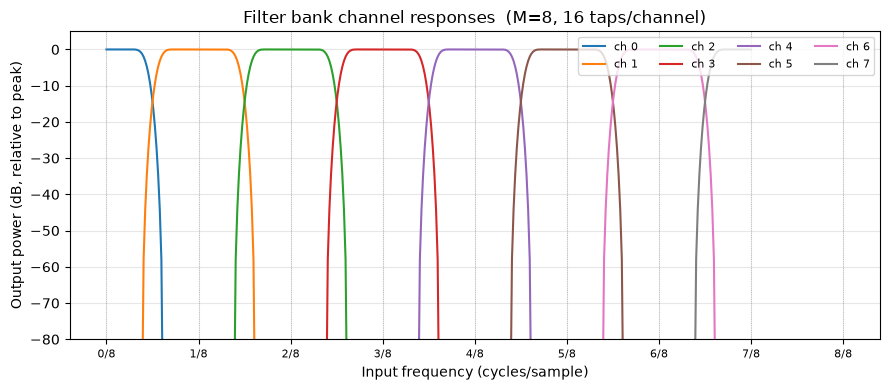

In [2]:
analysis = PolyphaseAnalysisChannelizer.from_design(
    num_channels=M, taps_per_channel=TAPS_PER_CHANNEL
)

N_sweep = 4096
n_sweep = np.arange(N_sweep)
freqs_norm = np.linspace(0, 1 - 1 / M, 400)
transient = 50

sweep_energy = np.zeros((len(freqs_norm), M))
for i, f in enumerate(freqs_norm):
    x = np.exp(1j * 2 * np.pi * f * n_sweep)
    y = analysis.process(x)
    sweep_energy[i] = np.mean(np.abs(y[:, transient:]) ** 2, axis=1)

sweep_db = 10 * np.log10(np.maximum(sweep_energy, 1e-12) / sweep_energy.max())

fig, ax = plt.subplots(figsize=(9, 4))
for k in range(M):
    ax.plot(freqs_norm, sweep_db[:, k], label=f"ch {k}")
for k in range(M + 1):
    ax.axvline(k / M, color="gray", linestyle=":", linewidth=0.6, alpha=0.5)
ax.set_xlabel("Input frequency (cycles/sample)")
ax.set_ylabel("Output power (dB, relative to peak)")
ax.set_title(f"Filter bank channel responses  (M={M}, {TAPS_PER_CHANNEL} taps/channel)")
ax.set_ylim(-80, 5)
ax.set_xticks([k / M for k in range(M + 1)])
ax.set_xticklabels([f"{k}/{M}" for k in range(M + 1)], fontsize=8)
ax.legend(ncol=4, fontsize=8, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()

## Multi-tone input signal

We construct a composite baseband signal with four tones:

| Tone | Frequency | Location |
|------|-----------|----------|
| A | 1/8 | channel 1 bin center |
| B | 3/8 | channel 3 bin center |
| C | 6/8 | channel 6 bin center |
| D | 2.5/8 | boundary between channels 2 and 3 |

Tone D sits in the transition band of the prototype filter relative to both channel 2
and channel 3. It will appear near each channel's Nyquist edge with an amplitude
set by the filter's attenuation there — demonstrating that the channelizer is not
just a frequency router but a filter bank.

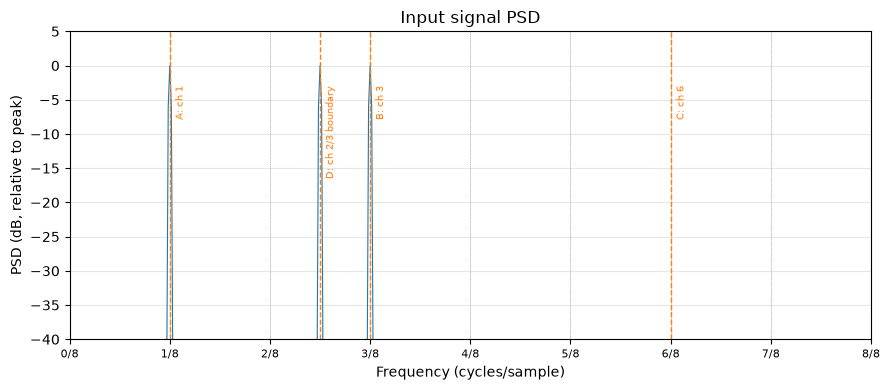

In [3]:
N = 8192
rng = np.random.default_rng(42)
n = np.arange(N)

tone_freqs  = [1/M, 3/M, 6/M, 2.5/M]
tone_labels = ["A: ch 1", "B: ch 3", "C: ch 6", "D: ch 2/3 boundary"]

x = sum(np.exp(1j * 2 * np.pi * f * n) for f in tone_freqs)
x = x + 0.05 * (rng.standard_normal(N) + 1j * rng.standard_normal(N))

f_in, P_in = welch(x, fs=1.0, nperseg=512, return_onesided=False)
order = np.argsort(f_in)
f_in, P_in = f_in[order], P_in[order]
P_in_db = 10 * np.log10(P_in / P_in.max())

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(f_in, P_in_db, linewidth=0.8, color="C0")
for k in range(M + 1):
    ax.axvline(k / M, color="gray", linestyle=":", linewidth=0.6, alpha=0.5)
for f, lbl in zip(tone_freqs, tone_labels):
    ax.axvline(f, color="C1", linestyle="--", linewidth=1)
    ax.text(f + 0.006, -3, lbl, rotation=90, fontsize=7, va="top", color="C1")
ax.set_xlabel("Frequency (cycles/sample)")
ax.set_ylabel("PSD (dB, relative to peak)")
ax.set_title("Input signal PSD")
ax.set_xlim(0, 1)
ax.set_xticks([k / M for k in range(M + 1)])
ax.set_xticklabels([f"{k}/{M}" for k in range(M + 1)], fontsize=8)
ax.set_ylim(-40, 5)
ax.grid(True, alpha=0.3)
plt.tight_layout()

## Per-channel output PSDs

After channelization the output has shape `(M, num_blocks)` with `num_blocks ≈ N / D`.
Each channel's frequency axis runs from −0.5 to +0.5 **cycles/channel-sample**
(the decimated sample rate); 0 Hz in a channel corresponds to that channel's
center frequency in the wideband signal.

A tone at a channel's bin center arrives at DC in that channel. Tone D, which sat
at the 2/3 boundary, arrives near ±Nyquist (±0.5 cycles/channel-sample) in both
channels 2 and 3 — attenuated by how far the prototype filter's stopband has rolled
off at that edge.

Input:  8192 samples  @ fs
Output: (8, 1024)  (8 channels × 1024 blocks @ fs/8)


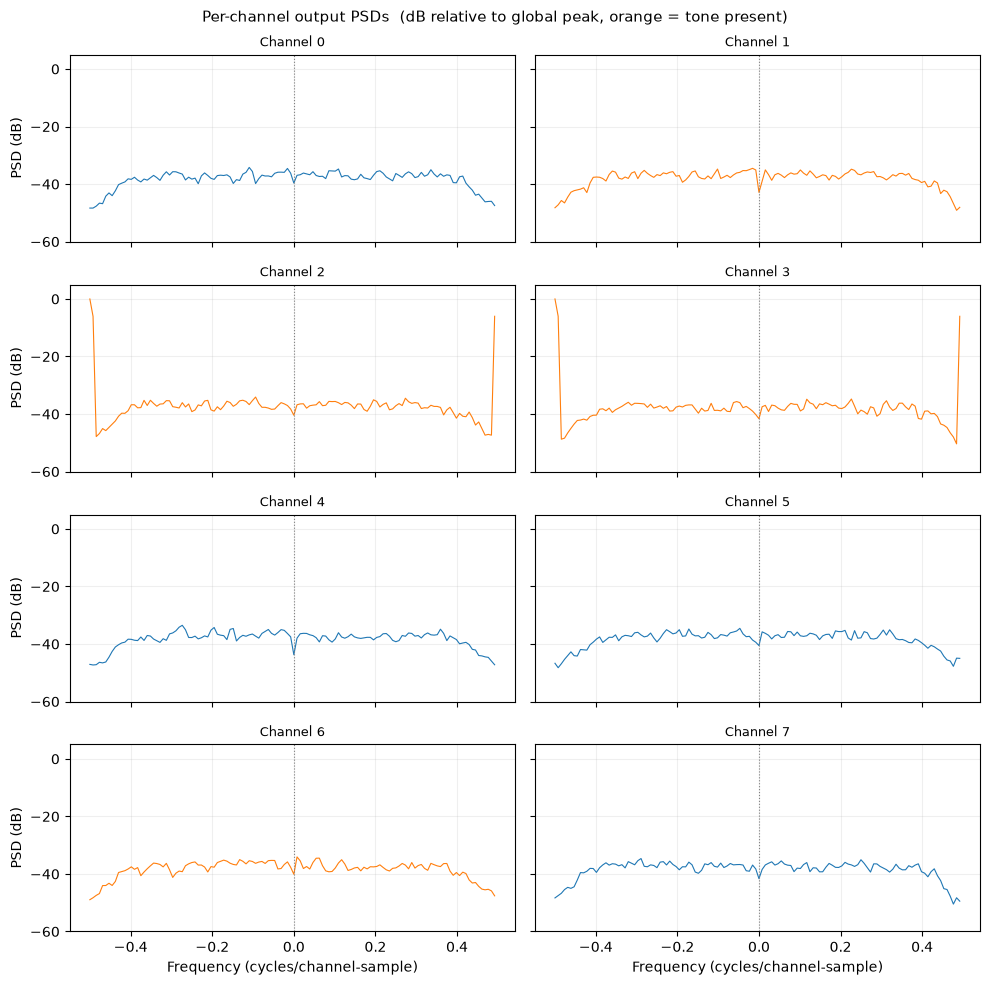

In [4]:
y = analysis.process(x)
print(f"Input:  {N} samples  @ fs")
print(f"Output: {y.shape}  ({M} channels × {y.shape[1]} blocks @ fs/{M})")

transient = 50
nperseg = 128

# Compute all PSDs and find global max for a shared dB reference
psds = []
for k in range(M):
    ch = y[k, transient:]
    f_ch, P_ch = welch(ch, fs=1.0, nperseg=nperseg, return_onesided=False)
    order = np.argsort(f_ch)
    psds.append((f_ch[order], P_ch[order]))

global_max = max(P_ch.max() for _, P_ch in psds)

boundary_channels = {2, 3}   # channels that see tone D
active_channels   = {1, 3, 6} | boundary_channels

fig, axes = plt.subplots(4, 2, figsize=(10, 10), sharex=True, sharey=True)
for k, ax in enumerate(axes.flat):
    f_ch, P_ch = psds[k]
    color = "C1" if k in active_channels else "C0"
    ax.plot(f_ch, 10 * np.log10(P_ch / global_max), linewidth=0.8, color=color)
    ax.axvline(0, color="gray", linestyle=":", linewidth=0.8)
    ax.set_title(f"Channel {k}", fontsize=9)
    ax.set_ylim(-60, 5)
    ax.grid(True, alpha=0.2)

for ax in axes[-1]:
    ax.set_xlabel("Frequency (cycles/channel-sample)")
for ax in axes[:, 0]:
    ax.set_ylabel("PSD (dB)")

fig.suptitle(
    "Per-channel output PSDs  (dB relative to global peak, orange = tone present)",
    fontsize=11,
)
plt.tight_layout()